In [1]:
import os
import gc
import sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../")))
from srlib.dataset.loading import load_srcnn_dataset
from srlib.dataset.visualization import plot_patch_pairs
from srlib.deep_learning.srcnn import SRCNNModel
from srlib.constants import (
    CLASS_LABELS_PATH,
    HR_ROOT,
    LR_ROOT,
    SRCNN_PATCH_SIZE,
    SRCNN_STRIDE,
)

In [2]:
# X -> Low-resolution patches (model input), upscaled to the HR frame size
# Y -> High-resolution patches (target)
# The LR side uses SRCNN_UPSCALE_INTERPOLATION, the same value
# super_resolve_image uses at inference time. No per-image degradation kernel
# is read: it does not exist for a real low-resolution capture.
X_train, Y_train, X_val, Y_val, X_test, Y_test, hr_h, hr_w = load_srcnn_dataset(
    HR_ROOT,
    LR_ROOT,
    CLASS_LABELS_PATH,
    patch_size=SRCNN_PATCH_SIZE,
    stride=SRCNN_STRIDE,
)


 SRCNN dataset | patch 48, stride 48
  images    358 indexed -> 358 kept -> 289 train / 33 val / 36 test


  patches   28,900 train / 3,300 val / 3,600 test   of 48 x 48 x 3
  memory    1.67 GB
  range     X [0.0000, 1.0000]   Y [0.0000, 1.0000]
  frame     478 x 478
  done in 5.0s



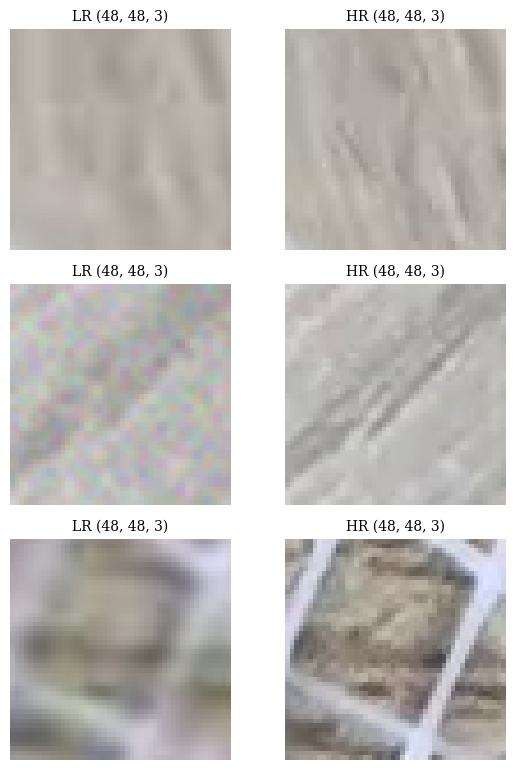

In [3]:
# What the model is actually fed: input on the left, its target on the right.
_ = plot_patch_pairs(X_train, Y_train, count=3, seed=0)

In [4]:
model = SRCNNModel()

model.setup_model(input_shape=X_train.shape[1:], learning_rate=1e-4)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 48, 48, 96)        23424     
                                                                 
 conv2d_1 (Conv2D)           (None, 48, 48, 32)        3104      
                                                                 
 conv2d_2 (Conv2D)           (None, 48, 48, 3)         2403      
                                                                 
Total params: 28,931
Trainable params: 28,931
Non-trainable params: 0
_________________________________________________________________


In [5]:
# Train SRCNN and capture callbacks for metrics
history, time_cb, mem_cb = model.fit(
    X_train, Y_train, X_val, Y_val,
    batch_size=32,
    epochs=100
)

Training on GPU: /physical_device:GPU:0
Epoch 1/100
904/904 [==============================] - 14s 9ms/step - loss: 0.0060 - psnr: 25.1956 - ssim: 0.7008 - val_loss: 0.0025 - val_psnr: 27.5267 - val_ssim: 0.7431 - lr: 1.0000e-04 - epoch_time_sec: 14.0443 - gpu_mean_current_mb: 1524.6112 - gpu_peak_mb: 1854.4819
Epoch 2/100
904/904 [==============================] - 8s 9ms/step - loss: 0.0022 - psnr: 28.2666 - ssim: 0.7469 - val_loss: 0.0023 - val_psnr: 27.9532 - val_ssim: 0.7482 - lr: 1.0000e-04 - epoch_time_sec: 7.6963 - gpu_mean_current_mb: 1698.4451 - gpu_peak_mb: 1874.1704
Epoch 3/100
904/904 [==============================] - 8s 9ms/step - loss: 0.0021 - psnr: 28.5172 - ssim: 0.7505 - val_loss: 0.0023 - val_psnr: 28.0640 - val_ssim: 0.7491 - lr: 1.0000e-04 - epoch_time_sec: 7.7442 - gpu_mean_current_mb: 1698.4451 - gpu_peak_mb: 1864.3269
Epoch 4/100
904/904 [==============================] - 7s 8ms/step - loss: 0.0021 - psnr: 28.6019 - ssim: 0.7516 - val_loss: 0.0023 - val_psnr: 2

In [6]:
del X_train, Y_train, X_val, Y_val  # Free memory
gc.collect()  # Force garbage collection to free memory

1488

In [7]:
# Evaluates the run, saves the checkpoint, the HR frame size and the metrics
# under one timestamp, so the reporting notebooks resolve a single run.
timestamp, run_dir, metrics = model.evaluate_and_save(
    X_test, Y_test, history, time_cb, mem_cb, hr_h, hr_w,
)


 SRCNN run 20260911_122117
  evaluating on the test partition
113/113 [==============================] - 1s 7ms/step - loss: 0.0022 - psnr: 28.7117 - ssim: 0.7757
Loss: 0.0022, PSNR: 28.71 dB, SSIM: 0.7757
Model saved to c:\Users\bgmanuel\MasterInteligenciaArtificial\Periodo2\TFM\Super-Resolution-Images-for-3D-Printing-Defect-Detection\models\SRCNN\SRCNN_20260911_122117\SRCNN_20260911_122117.h5
  frame size -> c:\Users\bgmanuel\MasterInteligenciaArtificial\Periodo2\TFM\Super-Resolution-Images-for-3D-Printing-Defect-Detection\models\SRCNN\SRCNN_20260911_122117\SRCNN_20260911_122117_hrh_hrw.pkl
  metrics    -> c:\Users\bgmanuel\MasterInteligenciaArtificial\Periodo2\TFM\Super-Resolution-Images-for-3D-Printing-Defect-Detection\models\SRCNN\SRCNN_20260911_122117\SRCNN_20260911_122117_metrics.pkl
  done in 1.0s

